### 二分类信息熵和基尼系数

In [70]:
import numpy as np
import matplotlib.pyplot as plt

In [71]:
def entropy(p): # 计算二分类的信息熵
    return -(p * np.log2(p) + (1 - p) * np.log2(1 - p))

In [72]:
def gini(p):    # 计算二分类情况下的基尼不纯度
    return 1 - p ** 2 - (1 - p) ** 2

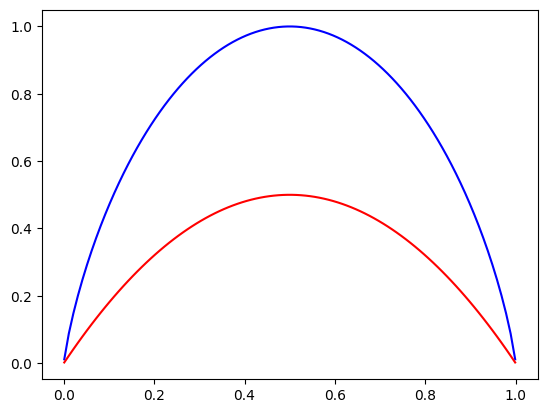

In [73]:
plot_x = np.linspace(0.001, 0.999, 100)          # 生成 0.001 ~ 0.999 之间的 100 个概率值
plt.plot(plot_x, entropy(plot_x), color='blue')  # 绘制熵曲线
plt.plot(plot_x, gini(plot_x), color='red')      # 绘制基尼不纯度曲线
plt.show()

### 数据集

In [74]:
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data[:, 1:3]
y = iris.target

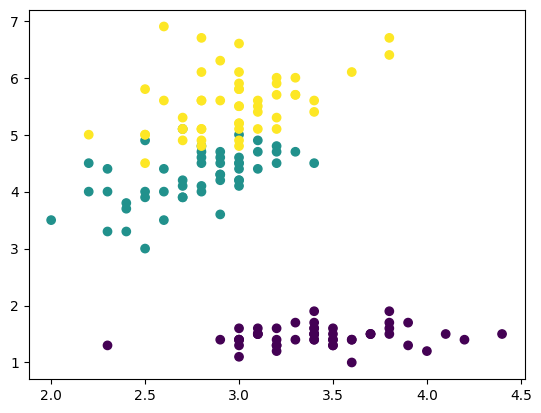

In [75]:
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()

### sklearn中的决策树（使用gini系数）

In [76]:
from sklearn.tree import DecisionTreeClassifier  # 导入决策树分类器
clf = DecisionTreeClassifier(
    max_depth=2,            # 最大树深度为 2
    criterion='gini')       # 使用基尼系数划分节点
clf.fit(X, y);              # 使用训练数据训练模型

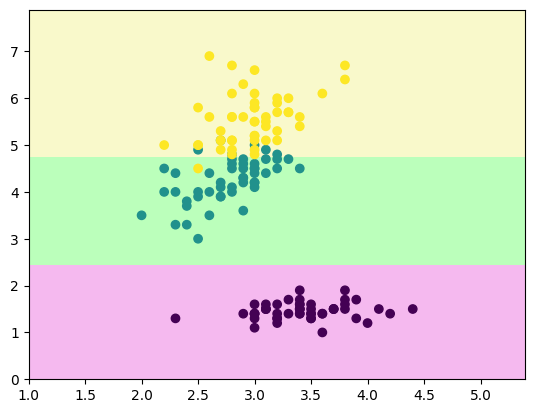

In [77]:
def decision_boundary_plot(X, y, clf):  # 获取两个特征的最小值和最大值，并向外扩展 1 个单位，作为绘图范围
    axis_x1_min, axis_x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    axis_x2_min, axis_x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    x1, x2 = np.meshgrid(    # 在两个特征范围内生成密集的二维网格点。步长越小，绘制出的决策边界越平滑
        np.arange(axis_x1_min, axis_x1_max, 0.01),
        np.arange(axis_x2_min, axis_x2_max, 0.01))
    # 将二维网格展开并组合成模型需要的二维特征数据，然后预测每一个网格点所属的类别
    z = clf.predict(np.c_[x1.ravel(), x2.ravel()])
    # 将预测结果恢复成与网格相同的形状，方便后续绘图
    z = z.reshape(x1.shape)

    from matplotlib.colors import ListedColormap
    custom_cmap = ListedColormap(['#F5B9EF', '#BBFFBB', '#F9F9CB'])  # 自定义三种类别对应的背景颜色

    plt.contourf(x1, x2, z, cmap=custom_cmap)  # 根据模型预测结果绘制不同类别的决策区域
    plt.scatter(X[:, 0], X[:, 1], c=y)  # 绘制原始样本点，颜色由真实类别 y 决定
    plt.show()
decision_boundary_plot(X, y, clf)

[Text(0.4, 0.8333333333333334, 'x[1] <= 2.45\ngini = 0.667\nsamples = 150\nvalue = [50, 50, 50]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 50\nvalue = [50, 0, 0]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[1] <= 4.75\ngini = 0.5\nsamples = 100\nvalue = [0, 50, 50]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.043\nsamples = 45\nvalue = [0, 44, 1]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.194\nsamples = 55\nvalue = [0, 6, 49]')]

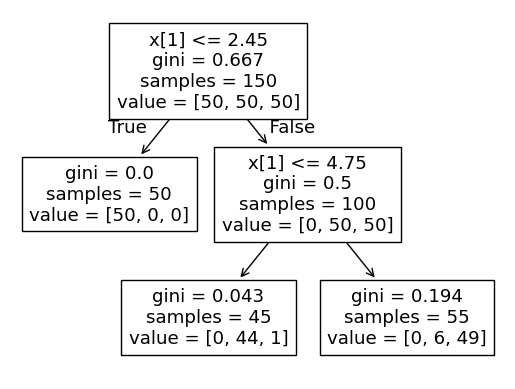

In [78]:
from sklearn.tree import plot_tree  # 导入决策树可视化函数
plot_tree(clf)  # 将训练好的决策树模型 clf 绘制成树状结构，可以查看每个节点的划分条件、样本数量和分类结果等信息

### 手动实现最优划分条件（特征选择）

In [79]:
from collections import Counter  # 导入 Counter，用于统计每个类别出现的次数
# 统计目标变量 y 中各类别的样本数量。例如：Counter({0: 50, 1: 50, 2: 50})
Counter(y)

Counter({np.int64(0): 50, np.int64(1): 50, np.int64(2): 50})

In [80]:
def calc_gini(y):
    counter = Counter(y)  # 统计每个类别出现的次数
    sum_gini = 1  # 基尼不纯度公式：Gini = 1 - Σ(p_i²)
    for i in counter:  # 遍历每个类别并计算其所占比例
        p = counter[i] / len(y)
        sum_gini -= p ** 2  # 减去该类别概率的平方
    return sum_gini  # 返回基尼不纯度

In [81]:
calc_gini(y)  # 计算 y 的基尼不纯度

0.6666666666666665

In [82]:
def split_dataset(X, y, dim, value):
    index_left = (X[:, dim] <= value)  # 找出指定特征中，小于等于划分值的样本位置
    index_right = (X[:, dim] > value)  # 找出指定特征中，大于划分值的样本位置
    return X[index_left], y[index_left], X[index_right], y[index_right]  # 分别返回左侧和右侧的特征数据与标签数据

In [83]:
def find_best_split(X, y):  # 初始化“最优划分”相关变量
    best_dim = -1
    best_value = -1
    best_gini = np.inf
    best_gini_left, best_gini_right = -1, -1

    for dim in range(X.shape[1]):  # 遍历数据集中的每一个特征
        sorted_index = np.argsort(X[:, dim])  # 按当前特征值从小到大排序，并返回排序后的索引
        for i in range(X.shape[0] - 1):  # 遍历相邻样本，寻找可能的划分位置
            value_left, value_right = (X[sorted_index[i], dim], X[sorted_index[i + 1], dim])

            if value_left != value_right:  # 相邻两个特征值不相同时，才需要尝试划分
                value = (value_left + value_right) / 2  # 使用两个相邻特征值的中点作为候选划分阈值
                # 根据当前特征和阈值，将数据划分为左右两个子数据集
                X_left, y_left, X_right, y_right = split_dataset(X, y, dim, value)
                # 分别计算左右子数据集的熵
                gini_left, gini_right = (calc_gini(y_left),calc_gini(y_right))
                # 根据左右子数据集的样本数量，计算划分后的加权平均熵
                gini = (len(X_left) * gini_left + len(X_right) * gini_right) / X.shape[0]
                if gini < best_gini:  # 如果当前gini更小，则更新最优划分条件
                    best_dim = dim
                    best_value = value
                    best_gini = gini
                    best_gini_left = gini_left
                    best_gini_right = gini_right
    # 返回最优特征、最优阈值、最小加权熵，以及左右子节点的熵
    return (best_dim, best_value, best_gini, best_gini_left, best_gini_right)

In [84]:
# 寻找整个数据集的最优划分条件。返回：最优特征索引、最优阈值、最小加权熵、左子集熵、右子集熵
find_best_split(X, y)

(1, np.float64(2.45), 0.3333333333333333, 0.0, 0.5)

In [85]:
# 按照第 2 个特征、阈值 2.45，将数据划分为左右两个子数据集
X_left, y_left, X_right, y_right = split_dataset(X, y, 1, 2.45)

In [86]:
# 对右侧子数据集继续寻找最优划分条件，相当于继续构建决策树的下一层
find_best_split(X_right, y_right)

(1,
 np.float64(4.75),
 0.12646464646464653,
 0.04345679012345684,
 0.19438016528925628)